# Practice 3.
## Objectives:
1. Learn to deal with dates
2. Deal with *colinearity*
3. Do a simple Linear regression

Aplication:
Data basse: Data set from the UCI Machine Learning Repository (http://archive.ics.uci.edu/ml)

Appliances energy prediction Data Set: http://archive.ics.uci.edu/ml/datasets/Appliances+energy+prediction#
Predict **Appliances energy consumption in Watts/hour**.
Database: Wine quality, http://archive.ics.uci.edu/ml/datasets/Wine+Quality
Predict quality (score between 0 and 10)

In [2]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

In [3]:
File = "energydata_complete.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')

Filename with path: 
 c:\Users\Marcel\Uni\Master\MLEARN\MLEARN\Practicas\ThirdPractice\Data\energydata_complete.csv


In [5]:
Data = pd.read_csv(Filename)
Data.head().T

,0,1,2,3,4
date,2016-01-11 17:00:00,2016-01-11 17:10:00,2016-01-11 17:20:00,2016-01-11 17:30:00,2016-01-11 17:40:00
Appliances,60,60,50,50,60
lights,30,30,30,40,40
T1,19.89,19.89,19.89,19.89,19.89
RH_1,47.596667,46.693333,46.3,46.066667,46.333333
T2,19.2,19.2,19.2,19.2,19.2
RH_2,44.79,44.7225,44.626667,44.59,44.53
T3,19.79,19.79,19.79,19.79,19.79
RH_3,44.73,44.79,44.933333,45.0,45.0
T4,19.0,19.0,18.926667,18.89,18.89


## First we clean the date feature into something usefull

In [6]:
pd.to_datetime(Data['date'])

0       2016-01-11 17:00:00
1       2016-01-11 17:10:00
2       2016-01-11 17:20:00
3       2016-01-11 17:30:00
4       2016-01-11 17:40:00
                ...        
19730   2016-05-27 17:20:00
19731   2016-05-27 17:30:00
19732   2016-05-27 17:40:00
19733   2016-05-27 17:50:00
19734   2016-05-27 18:00:00
Name: date, Length: 19735, dtype: datetime64[us]

## Some usefull tools for dealing with dates.
###  We will use lambda functions. Take a look at https://en.wikipedia.org/wiki/Anonymous_function

In [7]:
date_raw = pd.to_datetime(Data['date'])
date_raw.map(lambda x: x.day)


0        11
1        11
2        11
3        11
4        11
         ..
19730    27
19731    27
19732    27
19733    27
19734    27
Name: date, Length: 19735, dtype: int64

In [8]:
day_month = date_raw.map(lambda x: x.day)
day_week = date_raw.map(lambda x: x.dayofweek)
hour_day = date_raw.map(lambda x: x.hour)
Data['day_month'] = day_month
Data['day_week'] = day_week
Data['hour_day'] = hour_day

## Trick for solving that 24h is equal to 0h
Distances in time should be consistent.  23:50 is at 10 minutes from midnight, also 0:10
        

In [9]:
#Data['hour_day_cos'] = np.cos(2*np.pi*hour_day/24.)
#Data['hour_day_sin'] = np.sin(2*np.pi*hour_day/24.)
Data['Time from Midning'] = np.sqrt(
                            np.power(np.sin(2*np.pi*hour_day/24.),2) + 
                            np.power(1.-np.cos(2*np.pi*hour_day/24.),2))

<font color='green'> Deberíamos hacer ciclicas tambien las variables day_week y day_month?
Además de hacer la variable month? podría ser útil </font>

In [10]:
Data.drop(columns = ['date','rv1','rv2'])

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,day_month,day_week,hour_day,Time from Midning
0,60,30,19.890000,47.596667,19.200000,44.790000,19.790000,44.730000,19.000000,45.566667,...,6.600000,733.5,92.000000,7.000000,63.000000,5.300000,11,0,17,1.586707
1,60,30,19.890000,46.693333,19.200000,44.722500,19.790000,44.790000,19.000000,45.992500,...,6.483333,733.6,92.000000,6.666667,59.166667,5.200000,11,0,17,1.586707
2,50,30,19.890000,46.300000,19.200000,44.626667,19.790000,44.933333,18.926667,45.890000,...,6.366667,733.7,92.000000,6.333333,55.333333,5.100000,11,0,17,1.586707
3,50,40,19.890000,46.066667,19.200000,44.590000,19.790000,45.000000,18.890000,45.723333,...,6.250000,733.8,92.000000,6.000000,51.500000,5.000000,11,0,17,1.586707
4,60,40,19.890000,46.333333,19.200000,44.530000,19.790000,45.000000,18.890000,45.530000,...,6.133333,733.9,92.000000,5.666667,47.666667,4.900000,11,0,17,1.586707
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19730,100,0,25.566667,46.560000,25.890000,42.025714,27.200000,41.163333,24.700000,45.590000,...,22.733333,755.2,55.666667,3.333333,23.666667,13.333333,27,4,17,1.586707
19731,90,0,25.500000,46.500000,25.754000,42.080000,27.133333,41.223333,24.700000,45.590000,...,22.600000,755.2,56.000000,3.500000,24.500000,13.300000,27,4,17,1.586707
19732,270,10,25.500000,46.596667,25.628571,42.768571,27.050000,41.690000,24.700000,45.730000,...,22.466667,755.2,56.333333,3.666667,25.333333,13.266667,27,4,17,1.586707
19733,420,10,25.500000,46.990000,25.414000,43.036000,26.890000,41.290000,24.700000,45.790000,...,22.333333,755.2,56.666667,3.833333,26.166667,13.233333,27,4,17,1.586707


###  Surprise:  still is in the Dataframe
###  Trick: option 'inplace = True'  (more efficient in memory)

In [11]:
Data.head().T

,0,1,2,3,4
date,2016-01-11 17:00:00,2016-01-11 17:10:00,2016-01-11 17:20:00,2016-01-11 17:30:00,2016-01-11 17:40:00
Appliances,60,60,50,50,60
lights,30,30,30,40,40
T1,19.89,19.89,19.89,19.89,19.89
RH_1,47.596667,46.693333,46.3,46.066667,46.333333
T2,19.2,19.2,19.2,19.2,19.2
RH_2,44.79,44.7225,44.626667,44.59,44.53
T3,19.79,19.79,19.79,19.79,19.79
RH_3,44.73,44.79,44.933333,45.0,45.0
T4,19.0,19.0,18.926667,18.89,18.89


## Lets look at the histogram of Appliances

1. **Note that there are outliers**  
2. **Linear regression does not work well with outliers of high value**
3. **The distribution is not Gaussian**

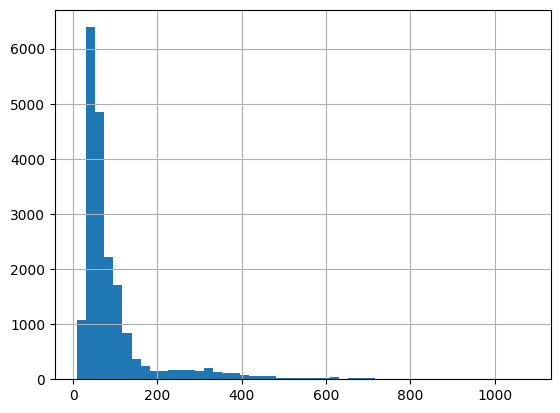

In [12]:
ax = Data['Appliances'].hist(bins = 50)

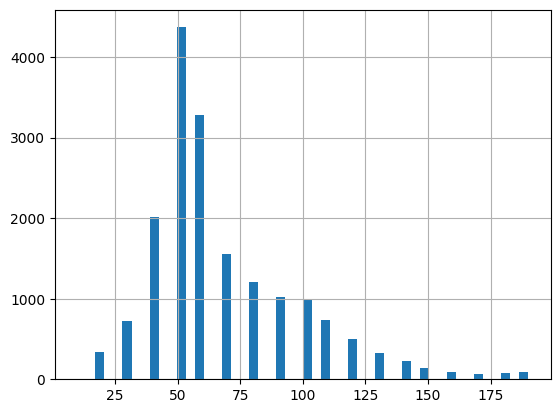

In [13]:
Threshold = 200
Data = Data[Data['Appliances']<Threshold]
ax = Data['Appliances'].hist(bins = 50)

In [14]:
Data.drop(columns = ['date','rv1','rv2'],inplace = True)


## Feature engineering by using (known) interactions

In [15]:
Data['Press_mm_hg'] = Data['Press_mm_hg']/10.
Data['lightsXPress_mm_hg'] = Data['lights']*Data['Press_mm_hg']/100.
Data['Press_mm_hgXRH_out'] = Data['Press_mm_hg']*Data['RH_out']/100.
Data['Diff TempOutIn'] = np.mean(Data[['T1','T2','T3','T4','T5','T7','T9']].T)-(Data['T6']+Data['T_out'])/2
#Data['diff RH_OutIn'] = np.mean(Data[['RH_1','RH_2','RH_3','RH_4','RH_5','RH_7','RH_9']].T) - Data['RH_out']
Data.head().T

,0,1,2,3,4
Appliances,60.000000,60.000000,50.000000,50.000000,60.000000
lights,30.000000,30.000000,30.000000,40.000000,40.000000
T1,19.890000,19.890000,19.890000,19.890000,19.890000
RH_1,47.596667,46.693333,46.300000,46.066667,46.333333
T2,19.200000,19.200000,19.200000,19.200000,19.200000
RH_2,44.790000,44.722500,44.626667,44.590000,44.530000
T3,19.790000,19.790000,19.790000,19.790000,19.790000
RH_3,44.730000,44.790000,44.933333,45.000000,45.000000
T4,19.000000,19.000000,18.926667,18.890000,18.890000
RH_4,45.566667,45.992500,45.890000,45.723333,45.530000


## Exploratory analysis of the data

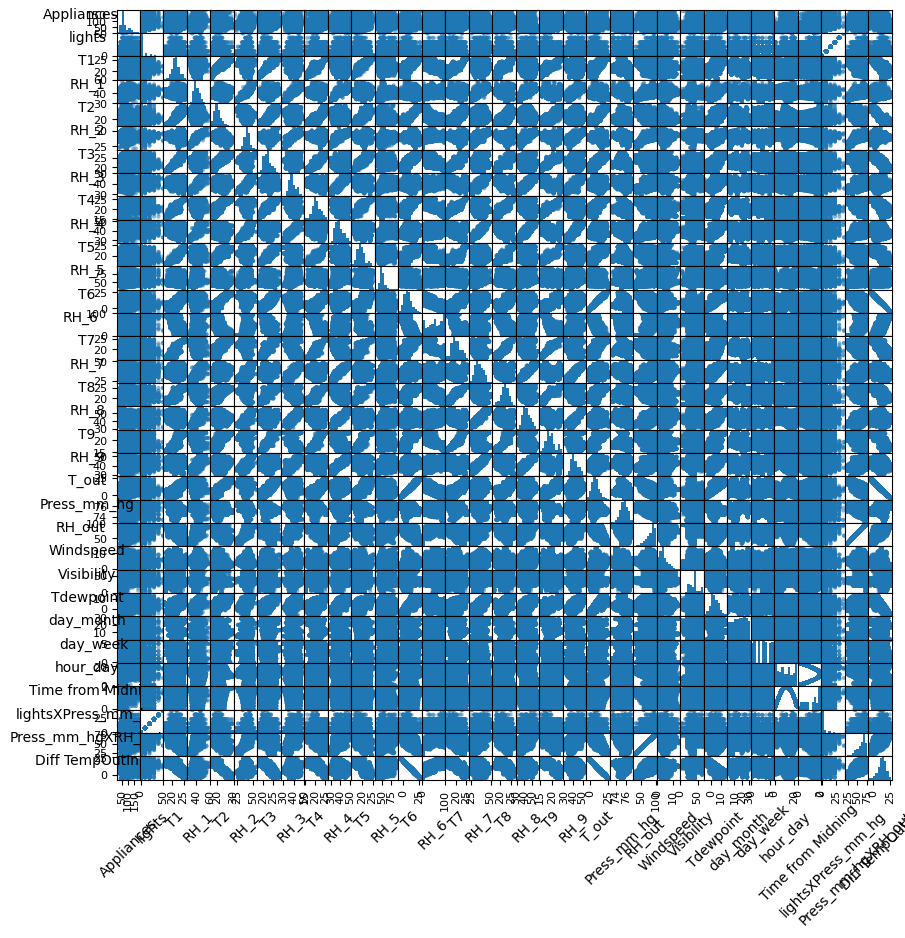

In [17]:
if True:
    ax = pd.plotting.scatter_matrix(Data,figsize = (10,10))
    for a in ax.ravel():
        a.set_xlabel(a.get_xlabel(), rotation=45)
        a.set_ylabel(a.get_ylabel(), rotation=0)

## Lets see subsets of the features
<font color='red'>**Task to be done**: </font>

<font color='red'>  - Detect colinearities </font>

<font color='red'>  - See if the gaussian hypothesis is valid from the histograms </font>

<font color='red'>###  Extract subsets with a list comprehension </font>

<font color='green'>Detect colinearity </font>

En el scatter plot podemos ver rápidamente las variables correladas, debido a que nos veremos los puntos repartidos de forma alteatoria rellenando todo el cuadro o en forma de circulo, sino que veremos lineas rectas (en caso de colinearidad muy alta) o ovalos muy esterchos (para colinearidad no tan alta).
Ejemplos de alta colinearidad son entre las siguientes parejas de variables: lights y pressure con la variable creada lightsXPress (como era obvio) igual que con la otra variable creadas como Diff Temperature o Press_mm_hg. Por otro lado tenemos todas las temperaturas, las cuales tienen una alta colinearidad entre si y a su vez con las humedades, ya sea positiva, cuando vemos que la recta crece (T1 y T2), o negativa cuando decrece (T1 y RH_6). Y finalmente destacar la clara colinearidad entre Time from midnight y hour_day, que era obvia al estar hablando en ambos casos de horas del día.

Además tambien podemos calcular la matriz de correlación para validar el resultado.

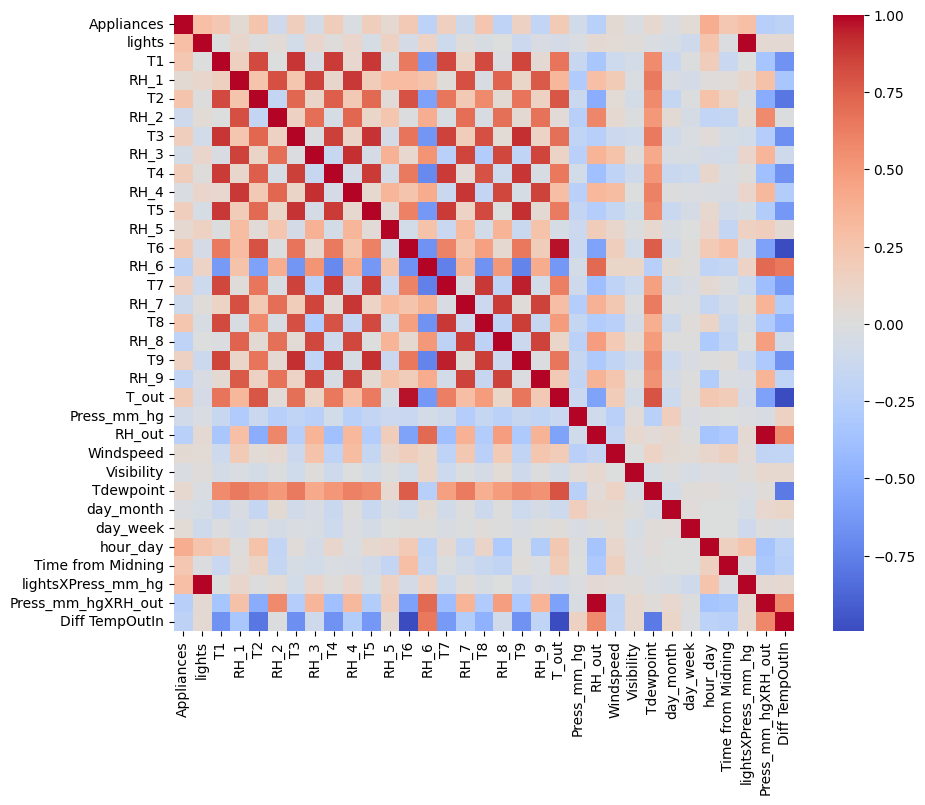

In [23]:
import seaborn as sns

if True:
    corr = Data.corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, cmap='coolwarm')

<font color='green'>Is the gaussian hypothesis valid from the histogram? </font>

Para ello podemos ver la diagonal del scatter plot o a su vez, dibujar el histograma para tenerlo mas claro.

En este segundo podemos ver como algunas temperaturas y humedades puede acercarse a tener una distribución gaussiana, aunque no del todo, ejemplos de ello son T1. RH_1 y RH_2. El resto de variables no acaban de tener la forma triangular que buscamos, tienen muchos picos o demasiados outliers

array([[<Axes: title={'center': 'Appliances'}>,
        <Axes: title={'center': 'lights'}>,
        <Axes: title={'center': 'T1'}>, <Axes: title={'center': 'RH_1'}>,
        <Axes: title={'center': 'T2'}>, <Axes: title={'center': 'RH_2'}>],
       [<Axes: title={'center': 'T3'}>, <Axes: title={'center': 'RH_3'}>,
        <Axes: title={'center': 'T4'}>, <Axes: title={'center': 'RH_4'}>,
        <Axes: title={'center': 'T5'}>, <Axes: title={'center': 'RH_5'}>],
       [<Axes: title={'center': 'T6'}>, <Axes: title={'center': 'RH_6'}>,
        <Axes: title={'center': 'T7'}>, <Axes: title={'center': 'RH_7'}>,
        <Axes: title={'center': 'T8'}>, <Axes: title={'center': 'RH_8'}>],
       [<Axes: title={'center': 'T9'}>, <Axes: title={'center': 'RH_9'}>,
        <Axes: title={'center': 'T_out'}>,
        <Axes: title={'center': 'Press_mm_hg'}>,
        <Axes: title={'center': 'RH_out'}>,
        <Axes: title={'center': 'Windspeed'}>],
       [<Axes: title={'center': 'Visibility'}>,
       

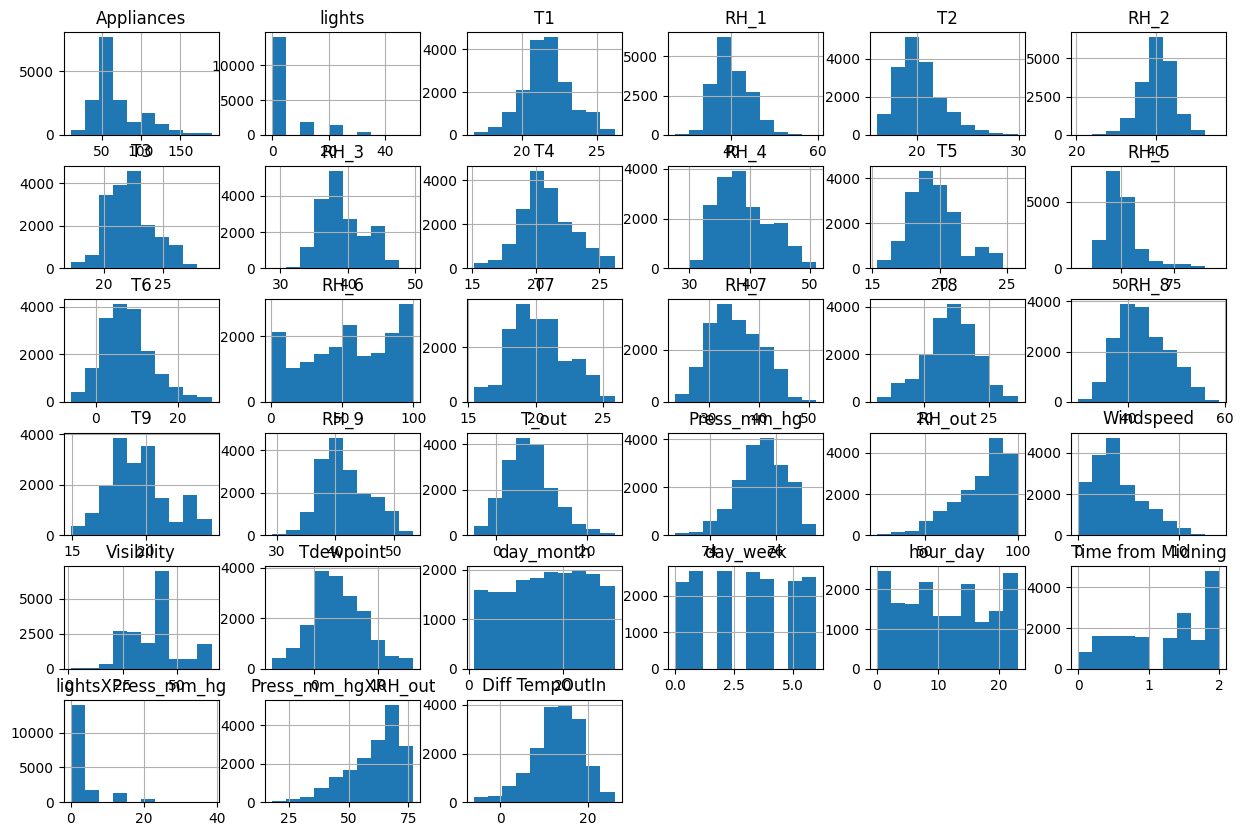

In [25]:
Data.hist(figsize=(15,10))

In [16]:
List_temprature = [ v for v in Data.columns.values if 'T' in v]
print(List_temprature)

['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T_out', 'Tdewpoint', 'Time from Midning', 'Diff TempOutIn']


### We append the target feature

In [17]:
List_temprature.append('Appliances')
print(List_temprature)

['T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'T_out', 'Tdewpoint', 'Time from Midning', 'Diff TempOutIn', 'Appliances']


In [18]:
df_temperatures = Data[List_temprature]

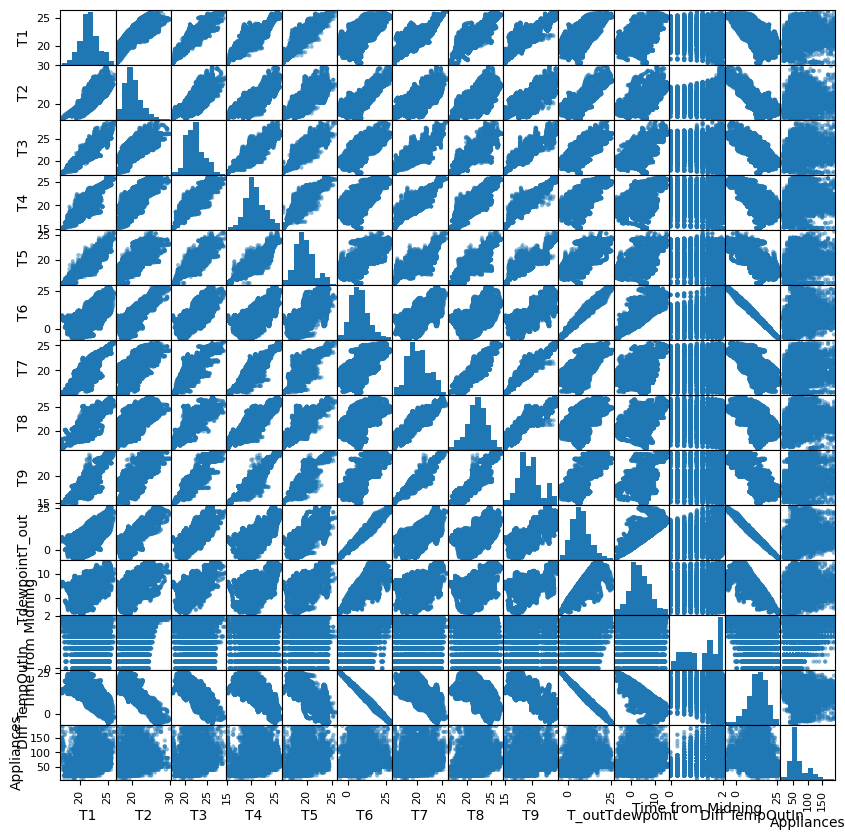

In [19]:
if True:
    ax = pd.plotting.scatter_matrix(df_temperatures,figsize = (10,10))

### Excercise: <font color='red'> Select subsets of features that of a common type (i.e. are correlated) </font>

<font color='green'> We can use the Temperature subset, but we are going to get the hummidity subset too in order to practica</font>


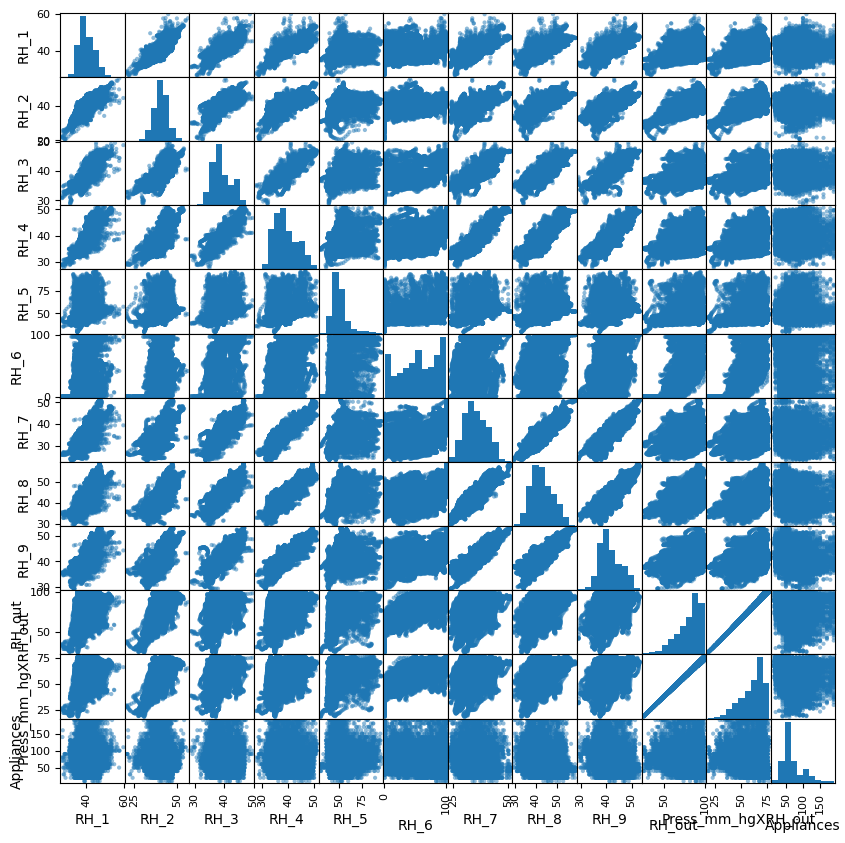

In [20]:
List_humidity = [ v for v in Data.columns.values if 'H' in v]
List_humidity.append('Appliances')
df_humidity = Data[List_humidity]
ax = pd.plotting.scatter_matrix(df_humidity,figsize = (10,10))

## First Estimate of the Output  with all the features

### Divide database into Train and test databases.

This is important in order to know how the model will behave with **unseen data**.

Note: there are more efficient and elegant methods for doing the partition, but we want to learn how to do basic processes with dataframes.

In [22]:
NumSamples, NumFeatures = Data.shape

### We generate the pointers for selecting the training and testing elements

In [23]:
Index = list(range(NumSamples))
print(Index[:10])
RandomIndex = np.random.permutation(Index)
print(RandomIndex[:10])

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
[17529  1740 12458   995   797  6517  7727  4297 12459  2053]


In [24]:
Fraction = 0.75
NumTrainElements = int(Fraction*NumSamples)
NumTestElements = NumSamples - NumTrainElements  # We will not need this variable
print(f'Number of training elements: {NumTrainElements}. Number of test elements:{NumTestElements}')

Number of training elements: 13320. Number of test elements:4441


### Take notice of how the elements are selected:

* Notation:  **Variable[:Number]**
* Notation: **Dataframe.loc[list]**

<font color='green'> Despues de separar los valores en entrenamiento y test asignamos indices aleatorios de la lista creada anteriormente RandomIndex, :NumTraingElements va del inicio --> El # de elemenos, en cambio NumTrainElements: va del # de elementos --> el final</font>
Ejemplo: NumTrainElements = 14751, toma índices RandomIndex[0] hasta RandomIndex[14750]

In [25]:
TrainIndex = RandomIndex[:NumTrainElements]
TestIndex = RandomIndex[NumTrainElements:]

<font color='green'> La función iloc: Selecciona todas las columnas pero solo las filas cuyos índices están en TrainIndex</font>

In [26]:
TrainDB = Data.iloc[TrainIndex]
TestDB = Data.iloc[TestIndex]

## Train the model and compute the explained variance $R^2$ and RMSE.

The $R^2$ is computed as follows:

1. $R^2(y, \hat{y}) = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$
2.  RMSE:  The root square of: $\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.$
**Note:** Try to learn how to write **latex** formulas.  It will very usefull.

In [27]:
y = TrainDB['Appliances']
InputFeatures = [fea for fea in Data.columns if 'Appliances' not in fea]
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]
reg = LinearRegression().fit(X, y)


 Input variables: 
 ['lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'day_month', 'day_week', 'hour_day', 'Time from Midning', 'lightsXPress_mm_hg', 'Press_mm_hgXRH_out', 'Diff TempOutIn']
__________________________________________________


### Performance in the train database

In [ ]:
print(f'explained variance R^2: {reg.score(X, y)*100.:2.2f} %')
Y_hat = reg.predict(X)
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
print('='*60)
print(f'Rank of the matrix: {reg.rank_} >  Number of features:{X.shape[1]}' )
print('Note: Rank is a concept of linear algebra related to the inverse of the matrix. \n You should be familliar with it.')
print('_'*60)

explained variance R^2: 39.10 %
RMSE : 23.91 
Rank of the matrix: 31 >  Number of features:32
Note: Rank is a concept of linear algebra related to the inverse of the matrix. 
 You should be familliar with it.
____________________________________________________________


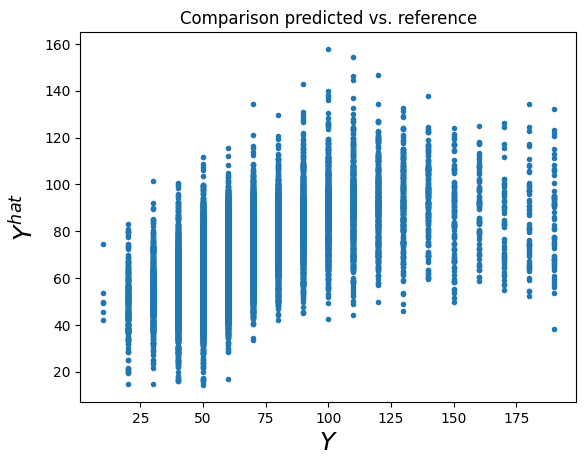

In [29]:
Y_hat = reg.predict(X)
plt.plot(y,Y_hat,'.')
plt.title('Comparison predicted vs. reference')
plt.ylabel('$Y^{hat}$', fontsize=18)
plt.xlabel('$Y$', fontsize=18)
plt.show()

<Axes: >

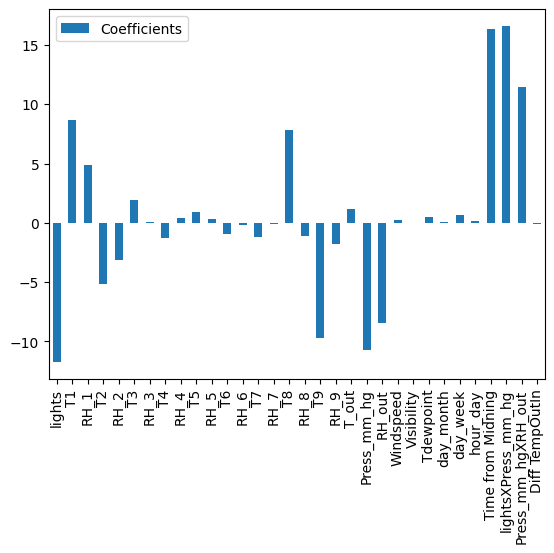

In [30]:
df = pd.DataFrame(data = reg.coef_, index = InputFeatures, columns = ['Coefficients'] )
df.plot.bar()

### Lets see how well it does with the test database.

We will give as performance features:
1. Explainee variance: $R^2$
2. RMSE:  The root square of: $\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.$

### Dataframe for comparing Performance

In [31]:
Performance = pd.DataFrame(index = ['R^2','RMSE'],columns = ['Regression','Ridge'])

explained variance $R^2$: 37.03 %
RMSE : 23.94 


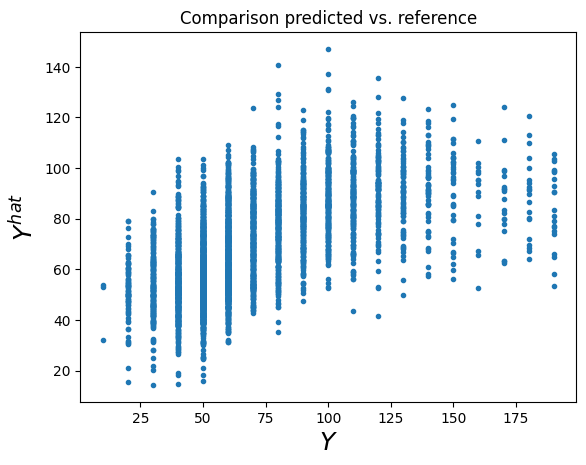

In [32]:
y = TestDB['Appliances']
X = TestDB[InputFeatures]
Y_hat = reg.predict(X)
print(f'explained variance $R^2$: {sklearn.metrics.r2_score(y, Y_hat)*100.:2.2f} %')
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
Performance.loc['R^2','Regression'] = reg.score(X, y)*100. 
Performance.loc['RMSE','Regression'] = np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat))

plt.plot(y,Y_hat,'.')
plt.title('Comparison predicted vs. reference')
plt.ylabel('$Y^{hat}$', fontsize=18)
plt.xlabel('$Y$', fontsize=18)
plt.show()

## Use a method that solves the problem of colinearity
### $W = (X^T X+ \lambda I)^{-1}X^Ty$
###  Name: Ridge regression

explained variance $R^2$: 38.84 %
RMSE : 23.96 
__________________________________________________


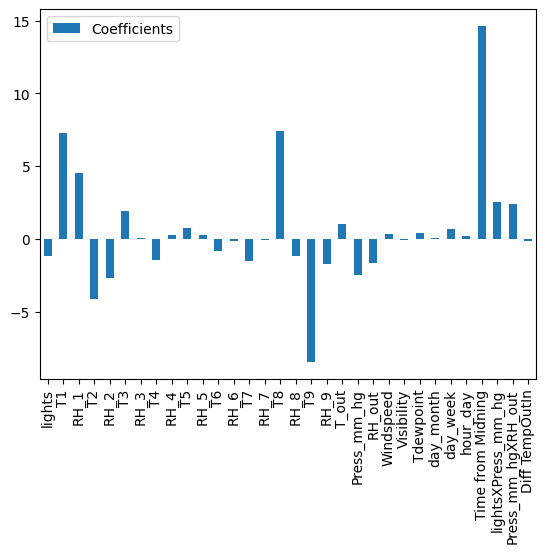

In [33]:
Lambda = 200.0
y = TrainDB['Appliances']
X = TrainDB[InputFeatures]
ridge = Ridge(alpha = Lambda).fit(X, y)
Y_hat = ridge.predict(X)
print(f'explained variance $R^2$: {ridge.score(X, y)*100.:2.2f} %')
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
print('_'*50)
df = pd.DataFrame(data = ridge.coef_, index = InputFeatures, columns = ['Coefficients'] )
ax = df.plot.bar()

### Ridge regression on the Test database

explained variance $R^2$: 37.20 %
RMSE : 23.90 


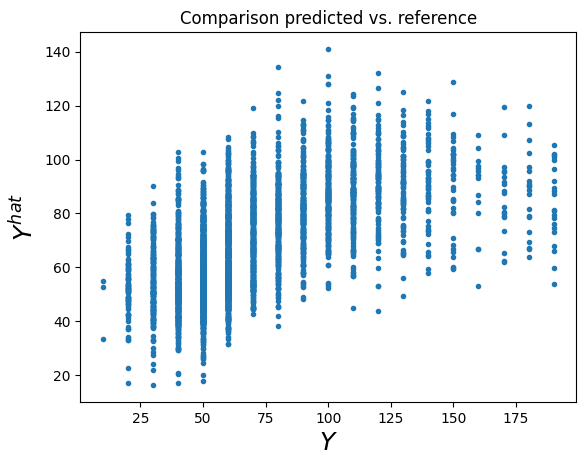

In [34]:
y = TestDB['Appliances']
X = TestDB[InputFeatures]
Y_hat = ridge.predict(X)
print(f'explained variance $R^2$: {sklearn.metrics.r2_score(y, Y_hat)*100.:2.2f} %')
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
Performance.loc['R^2','Ridge'] = ridge.score(X, y)*100. 
Performance.loc['RMSE','Ridge'] = np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat))

plt.plot(y,Y_hat,'.')
plt.title('Comparison predicted vs. reference')
plt.ylabel('$Y^{hat}$', fontsize=18)
plt.xlabel('$Y$', fontsize=18)
plt.show()

In [35]:
print('Comparison of performance on the test database')
Performance

Comparison of performance on the test database


,Regression,Ridge
R^2,37.025269,37.201176
RMSE,23.938443,23.904986


In [36]:
print('Comparison of the mean absolute value of the coefficients:')
print(f' Regression:{np.mean(abs(reg.coef_)):2.2f} > Ridge:{np.mean(abs(ridge.coef_)):2.2f}')


Comparison of the mean absolute value of the coefficients:
 Regression:4.00 > Ridge:2.26


## Exercise: <font color='red'> explain from the theory why the sum of the absolute values of the Ridge regression is lower than the regression.</font>  

## Exercise: <font color='green'> Los valores absolutos de la Ridge regression son inferiores debido a que el metodo incluye un termino de regularización, la λ, esto hace que matemáticamente las betas sean inferiores al ser la mtriz inversa ahora no solo XtX sino XtX + λI . Por tanto el modelo busca minimizar el error y evitar coefcientes grande. Además

En presencia de colinearidad entre variables, Ridge distribuye los pesos entre variables correlacionadas y por tanto reduce su magnitud, lo que acaba haciendo que la suma de los valores absolutos sea inferior.</font>  

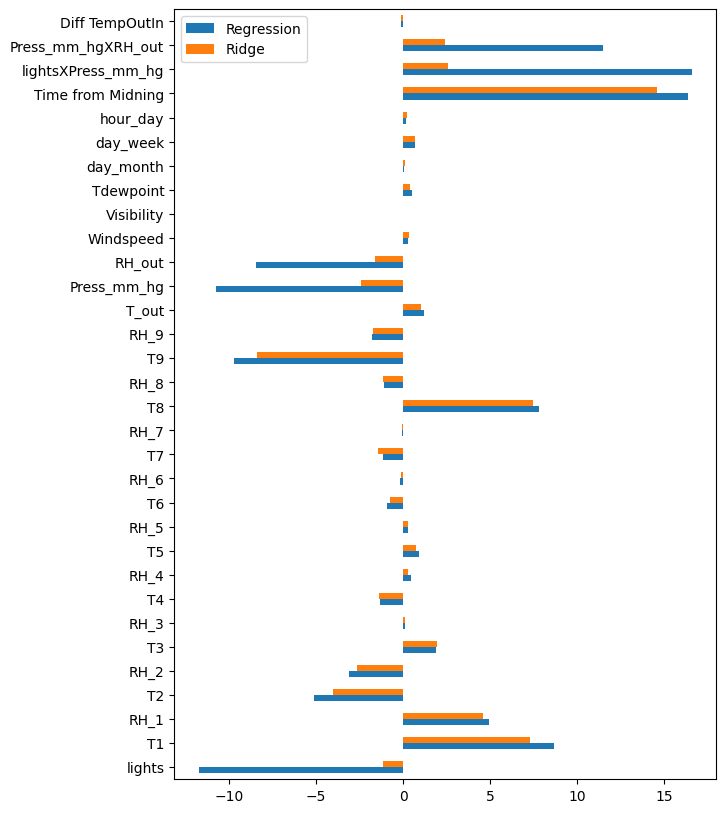

In [37]:
df = pd.DataFrame(index = InputFeatures,columns =['Regression','Ridge'])
df['Regression'] = reg.coef_
df['Ridge'] = ridge.coef_
ax = df.plot.barh(figsize = (7,10))

## Exercise: <font color='red'> Play with plotting 'bar()' vs 'barh()' vs '.plot.bar(stacked=True)' vs '.plot.barh(stacked=True)' </font>

## Exercise: <font color='red'> Change the threshold of the **outlier** filter and explain in words what happens (R², values of the coefficients)</font>

## Exercise: <font color='red'> What does it mean that the coefficients of related variables (i.e. T3 vs. T2, RH_1 vs RH_2) have different signs?</font> 
**Hint:** contrast

## Exercise: <font color='red'> Explain why Ridge is more robust to noise in comparison to regression.</font> 
**Hint:** size of contrasting coefficients

---

## Exercise: <font color='red'> Create a new model transforming the inputs, substitute the temperatures by mean temperature, the humidity by mean humidity. Compare size of coefficients and effect of the lambda</font> 

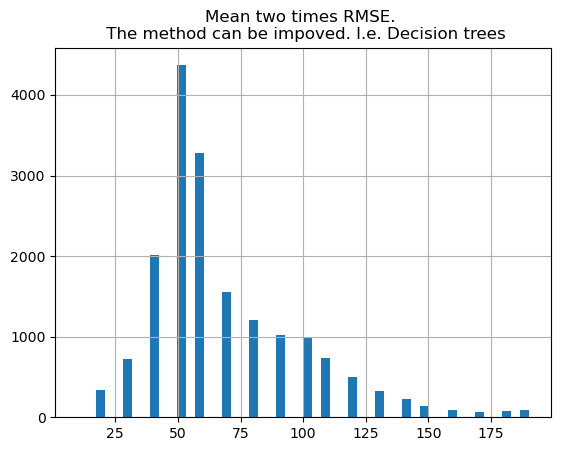

In [35]:

ax = Data['Appliances'].hist(bins = 50)
ax.set_title('Mean two times RMSE. \n The method can be impoved. I.e. Decision trees')
plt.show()

# Cross validation estimates

##  Cross-validation

###  Definition
Cross-validation is a statistical technique used in machine learning to evaluate how well a model generalizes to independent datasets.

1. It consists of dividing the training dataset into several parts, or folds, typically between 5 and 10 (See figure below).
<img src="EsquemaValidacioCreuada.png" width="60%">

2. One of the folds is reserved as a test set, while the rest are used to train the model. This process is repeated as many times as there are folds, so that each part of the dataset acts as a test set once.

3. Utility of validation:
   1. Detects overfitting, i.e., when a model adapts too much to the specific details of the training data and does not perform well with new examples.
   2. Through cross-validation, one can **better adjust the model parameters** to achieve a balance between fitting the training data and the ability to generalize.
   3. Allows creating more robust and reliable models, increasing confidence in the predictions made by these models in real-world situations.

Optimal Ridge alpha (lambda) found by cross-validation: 1.6298
explained variance $R^2$: 37.49 %
RMSE : 24.13 


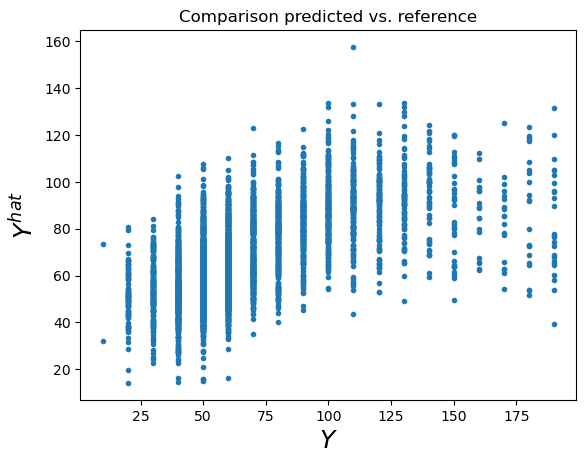

In [36]:
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold

# Define the range of alpha (lambda) values to test
alphas = np.logspace(-3, 3, 100)

# Create RidgeCV model that will automatically find the best alpha using cross-validation
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
y = TrainDB['Appliances']
X = TrainDB[InputFeatures]
ridge_cv.fit(X, y)

# Get the optimal alpha
optimal_alpha = ridge_cv.alpha_
print(f"Optimal Ridge alpha (lambda) found by cross-validation: {optimal_alpha:.4f}")

# Evaluate on test database
y = TestDB['Appliances']
X = TestDB[InputFeatures]
Y_hat = ridge_cv.predict(X)
print(f'explained variance $R^2$: {sklearn.metrics.r2_score(y, Y_hat)*100.:2.2f} %')
print(f'RMSE : {np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat)):2.2f} ' )
Performance.loc['R^2','Ridge'] = ridge_cv.score(X, y)*100. 
Performance.loc['RMSE','Ridge'] = np.sqrt(sklearn.metrics.mean_squared_error(y, Y_hat))

plt.plot(y,Y_hat,'.')
plt.title('Comparison predicted vs. reference')
plt.ylabel('$Y^{hat}$', fontsize=18)
plt.xlabel('$Y$', fontsize=18)
plt.show()

 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.


#  Appendix: Description of the features

Attribute Information:

date time year-month-day hour:minute:second


Appliances, energy use in Wh

lights, energy use of light fixtures in the house in Wh

T1, Temperature in kitchen area, in Celsius

RH_1, Humidity in kitchen area, in %

T2, Temperature in living room area, in Celsius

RH_2, Humidity in living room area, in %

T3, Temperature in laundry room area

RH_3, Humidity in laundry room area, in %

T4, Temperature in office room, in Celsius

RH_4, Humidity in office room, in %

T5, Temperature in bathroom, in Celsius

RH_5, Humidity in bathroom, in %

T6, Temperature outside the building (north side), in Celsius

RH_6, Humidity outside the building (north side), in %

T7, Temperature in ironing room , in Celsius

RH_7, Humidity in ironing room, in %

T8, Temperature in teenager room 2, in Celsius

RH_8, Humidity in teenager room 2, in %

T9, Temperature in parents room, in Celsius

RH_9, Humidity in parents room, in %

To, Temperature outside (from Chievres weather station), in Celsius

Pressure (from Chievres weather station), in mm Hg

RH_out, Humidity outside (from Chievres weather station), in %

Wind speed (from Chievres weather station), in m/s

Visibility (from Chievres weather station), in km

Tdewpoint (from Chievres weather station), Â°C

rv1, Random variable 1, nondimensional

rv2, Random variable 2, nondimensional